# Stereo template matching/block matching


In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage import data

plt.gray()

<Figure size 640x480 with 0 Axes>

Start by loading a set of corresponding left and right image. We also resize the images since the computations we expect to do can take a long time to process. Resizing is optional, but recommended atleast until you have verified your computer is capable of doing the computations within reasonable time.

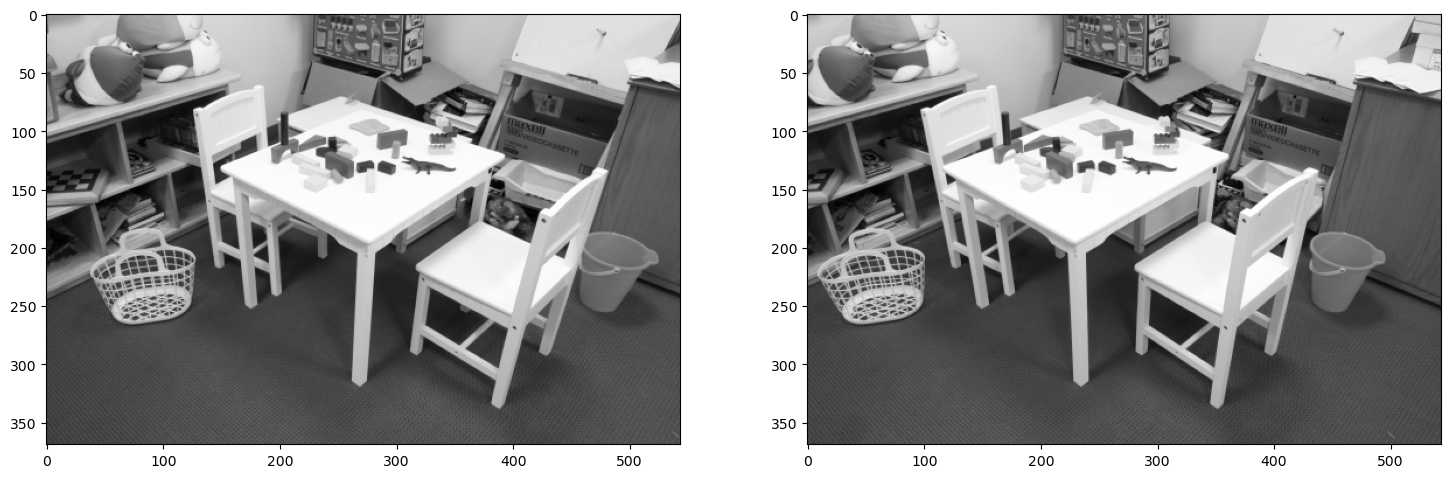

In [2]:
# load the images
img_left = cv2.imread("playtable_left.png")
img_right = cv2.imread("playtable_right.png")

# rescale images (can be left out)
img_size = (int(img_left.shape[1]/5), int(img_left.shape[0]/5))
img_left = cv2.resize(img_left, img_size, interpolation=cv2.INTER_AREA)
img_right = cv2.resize(img_right, img_size, interpolation=cv2.INTER_AREA)

# convert images to grayscale for template matching
gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

f, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(18,18))
ax_left.imshow(gray_left)
ax_right.imshow(gray_right)

Next step is to create a disparity map based on the two stereo images. This is done using the same procedure as we did with exercise 1, except now we look for blocks of pixel from the left image in the right image, or vice versa.

## Exercise 2.1
You will have to play with the below parameters until you find a good solution that gives a representative 3D projection. Reflect/search on what those parameters actually mean and how they influence the outcome.

# StereoBM

StereoBM: A fast, traditional block-matching algorithm that compares small windows between the left and right images to find disparities; simple and efficient but less accurate in low-texture or complex scenes.

# StereoSGBM

StereoSGBM: A more advanced “Semi-Global Block Matching” method that combines local matching with global smoothness constraints, producing smoother and more accurate disparity maps at higher computational cost.

Text(0.5, 1.0, 'Disparity Map (StereoBM)')

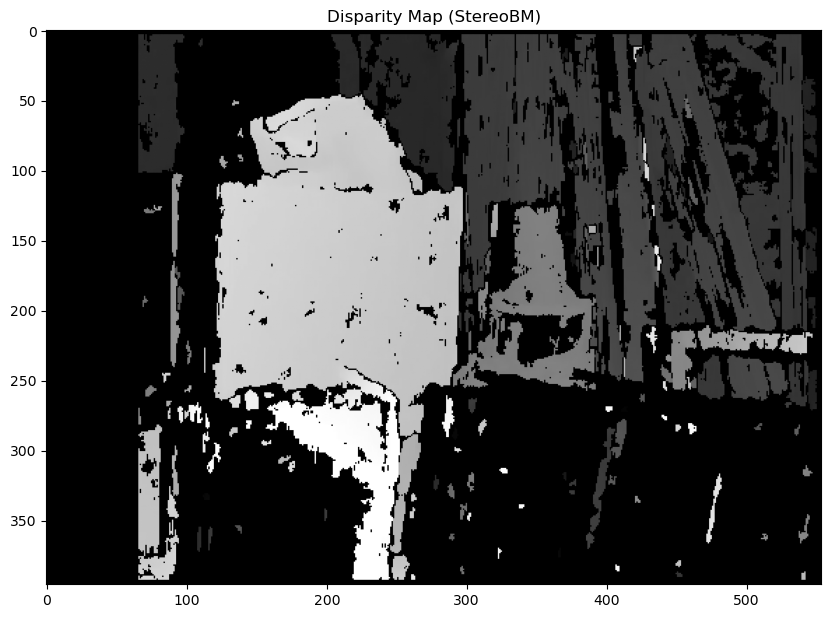

In [17]:
# Minimum possible disparity (how far left pixels can shift)
min_disp = 0

# Total number of disparities to search over (must be divisible by 16)
num_disp = 4 * 16    # here: 64 disparity levels

# Size of the matching window used in block matching (odd number, >=5)
block_size = 7

# Create the Stereo Block Matching (BM) matcher
stereo = cv2.StereoBM_create(
    numDisparities=num_disp,   # search range for disparities
    blockSize=block_size       # window size used to compare patches
)

# Set the minimum disparity offset
stereo.setMinDisparity(min_disp)

# Max allowed difference in the left→right vs right→left consistency check
stereo.setDisp12MaxDiff(10)

# Reject matches that are not significantly better than alternatives (uniqueness check)
stereo.setUniquenessRatio(30)   # higher = stricter

# Maximum disparity variation allowed within a speckle region (noise removal)
stereo.setSpeckleRange(4)

# Minimum size of a connected component to keep; small areas are removed as speckles
stereo.setSpeckleWindowSize(10)

# Compute disparity map and scale back because BM outputs disparity * 16
disp = stereo.compute(gray_left, gray_right).astype(np.float32) / 16.0

# Show disparity map
plt.figure(figsize=(10,10))
plt.imshow(disp)
plt.title("Disparity Map (StereoBM)")


## Exercise 2.2
Once you have a disparity map without too much noise, you can use the below to export you disparity map to a .ply file that you can load and display in a 3D visualization software (e.g. [Meshlab](https://www.meshlab.net/#description)).

**Hint:** To open meshlab type `meshlab` in a terminal. 
To vizualize the point cloud, drag the generated `out.ply` into the meshlab scene or click `File` > `Import Mesh` and navigate to where our source-code is located and open `out.ply`. 

In [4]:
def export_pointcloud(disparity_map, colors):
    ply_header = '''ply
    format ascii 1.0
    element vertex %(vert_num)d
    property float x
    property float y
    property float z
    property uchar red
    property uchar green
    property uchar blue
    end_header
    '''

    def write_ply(fn, verts, colors):
        verts = verts.reshape(-1, 3)
        colors = colors.reshape(-1, 3)
        verts = np.hstack([verts, colors])
        with open(fn, 'wb') as f:
            f.write((ply_header % dict(vert_num=len(verts))).encode('utf-8'))
            np.savetxt(f, verts, fmt='%f %f %f %d %d %d ')

    h, w = disparity_map.shape[:2]
    f = .8 * w  # guess for focal length. If you 3D reconstruction looks skewed in the viewing direction, try adjusting this parameter.
    Q = np.float32([[1, 0, 0, -0.5 * w],
                    [0, -1, 0, 0.5 * h],  # turn points 180 deg around x-axis,
                    [0, 0, 0, -f],  # so that y-axis looks up
                    [0, 0, 1, 0]])
    points = cv2.reprojectImageTo3D(disparity_map, Q)
    
    mask = disparity_map > disparity_map.min()
    out_points = points[mask]
    out_colors = colors[mask]
    out_fn = 'out.ply'
    write_ply('out.ply', out_points, out_colors)
    print(f'{out_fn} saved')

export_pointcloud(disparity_map=disp, colors=img_left)

out.ply saved


## Exercise 2.3

Create a disparity map of the imageset `storage` and display it in meshlab.

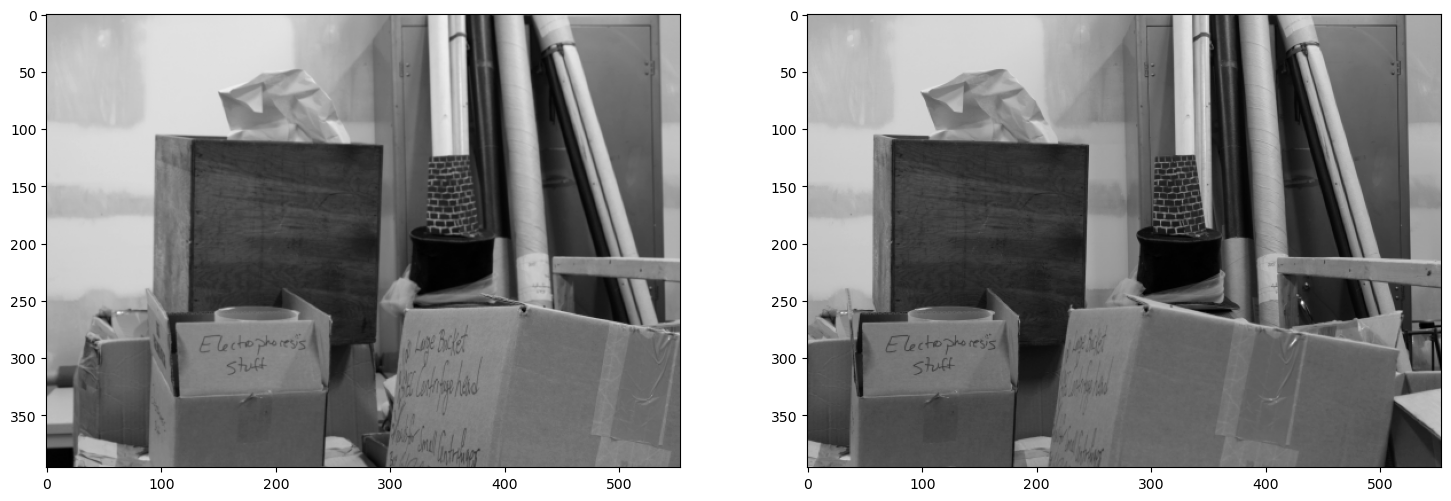

In [11]:
# load the images
img_left = cv2.imread("storage_left.png")
img_right = cv2.imread("storage_right.png")

# rescale images (can be left out)
img_size = (int(img_left.shape[1]/5), int(img_left.shape[0]/5))
img_left = cv2.resize(img_left, img_size, interpolation=cv2.INTER_AREA)
img_right = cv2.resize(img_right, img_size, interpolation=cv2.INTER_AREA)

# convert images to grayscale for template matching
gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

f, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(18,18))
ax_left.imshow(gray_left)
ax_right.imshow(gray_right)

Text(0.5, 1.0, 'Disparity Map (StereoBM)')

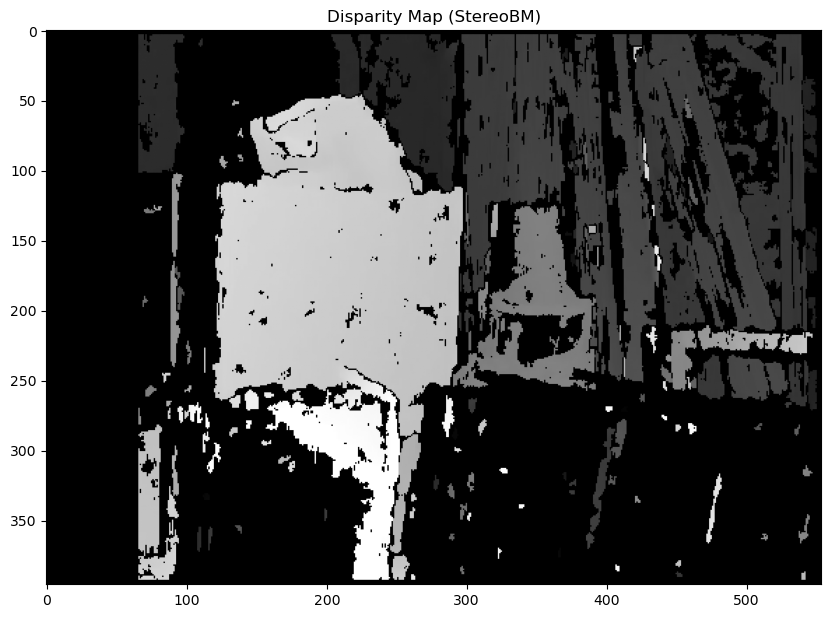

In [15]:
# Minimum possible disparity (how far left pixels can shift)
min_disp = 0

# Total number of disparities to search over (must be divisible by 16)
num_disp = 4 * 16    # here: 64 disparity levels

# Size of the matching window used in block matching (odd number, >=5)
block_size = 7

# Create the Stereo Block Matching (BM) matcher
stereo = cv2.StereoBM_create(
    numDisparities=num_disp,   # search range for disparities
    blockSize=block_size       # window size used to compare patches
)

# Set the minimum disparity offset
stereo.setMinDisparity(min_disp)

# Max allowed difference in the left→right vs right→left consistency check
stereo.setDisp12MaxDiff(10)

# Reject matches that are not significantly better than alternatives (uniqueness check)
stereo.setUniquenessRatio(30)   # higher = stricter

# Maximum disparity variation allowed within a speckle region (noise removal)
stereo.setSpeckleRange(4)

# Minimum size of a connected component to keep; small areas are removed as speckles
stereo.setSpeckleWindowSize(10)

# Compute disparity map and scale back because BM outputs disparity * 16
disp = stereo.compute(gray_left, gray_right).astype(np.float32) / 16.0

# Show disparity map
plt.figure(figsize=(10,10))
plt.imshow(disp)
plt.title("Disparity Map (StereoBM)")

# Other stereo method - StereoSGBM

StereoSGBM: A more advanced “Semi-Global Block Matching” method that combines local matching with global smoothness constraints, producing smoother and more accurate disparity maps at higher computational cost.

Text(0.5, 1.0, 'Disparity Map (StereoBM)')

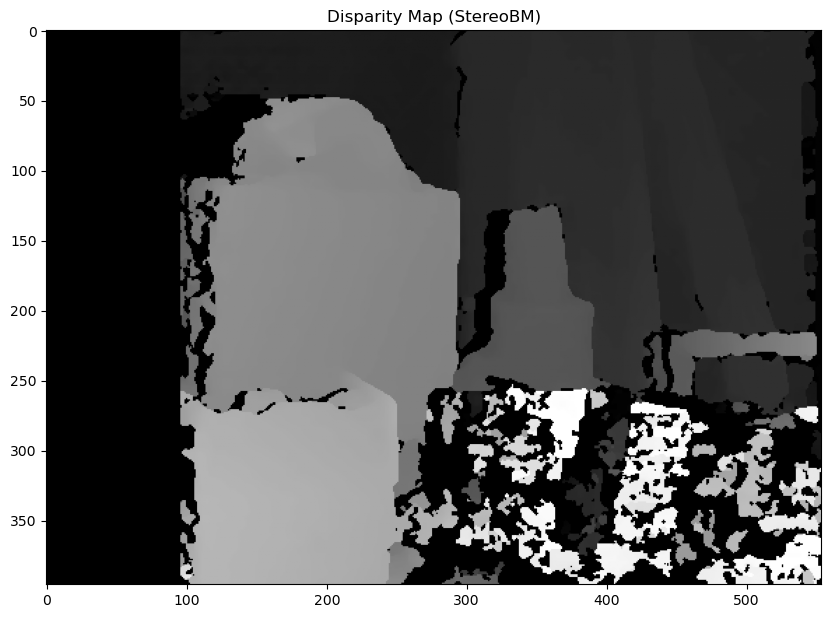

In [20]:
# Minimum possible disparity (starting offset for the search)
min_disp = 0

# Total number of disparities to search (must be divisible by 16)
num_disp = 6 * 16     # here: 96 disparity levels

# Size of the matching block (odd integer; controls local window)
block_size = 7

# Smoothness penalty for small disparity changes (encourages smooth surfaces)
P1 = 8 * block_size ** 2

# Smoothness penalty for larger disparity jumps (protects depth boundaries)
P2 = 32 * block_size ** 2

# Create the Semi-Global Block Matching (SGBM) stereo matcher
stereo = cv2.StereoSGBM_create(
    minDisparity=min_disp,        # minimum allowable disparity value
    numDisparities=num_disp,      # search range for disparities
    blockSize=block_size,         # local matching window size

    P1=P1,                        # penalty for disparity difference of 1 pixel
    P2=P2,                        # penalty for larger disparity differences

    disp12MaxDiff=1,              # left-right consistency tolerance
    uniquenessRatio=10,           # how much better the best match must be vs others
    speckleWindowSize=100,        # size of regions considered speckle noise
    speckleRange=32,              # disparity variation allowed within speckles

    mode=cv2.STEREO_SGBM_MODE_SGBM  # SGBM mode (regular semi-global matching)
)

# Compute disparity map and scale back because BM outputs disparity * 16
disp = stereo.compute(gray_left, gray_right).astype(np.float32) / 16.0

# Show disparity map
plt.figure(figsize=(10,10))
plt.imshow(disp)
plt.title("Disparity Map (StereoBM)")
